# Preparing

## Importing Libraries

In [30]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.graphics.regressionplots import influence_plot
from ISLP import load_data
import numpy as np
import matplotlib.pyplot as plt

## Importing Dataframe

In [31]:
df = load_data('Carseats')

df.dtypes

Sales           float64
CompPrice         int64
Income            int64
Advertising       int64
Population        int64
Price             int64
ShelveLoc      category
Age               int64
Education         int64
Urban          category
US             category
dtype: object

## Dummying

In [32]:
cols_categ = df.select_dtypes(include=['object', 'category']).columns.tolist()

df = pd.get_dummies(df, columns=cols_categ, drop_first=True, dtype=int)

df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,9.50,138,73,11,276,120,42,17,0,0,1,1
1,11.22,111,48,16,260,83,65,10,1,0,1,1
2,10.06,113,35,10,269,80,59,12,0,1,1,1
3,7.40,117,100,4,466,97,55,14,0,1,1,1
4,4.15,141,64,3,340,128,38,13,0,0,1,0


# Answers

### a) Fit a multiple regression model to predict Sales using Price,Urban, and US.

In [33]:
df_feats = df[['Sales', 'Price', 'Urban_Yes', 'US_Yes']]

y = df['Sales']

X = df[['Price', 'Urban_Yes', 'US_Yes']]

X_const = sm.add_constant(X)

lin_reg_model = sm.OLS(y, X_const)

results = lin_reg_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           2.39e-23
Time:                        05:01:55   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0435      0.651     20.036      0.0

### b) Provide an interpretation of each coefficient in the model. Be careful—some of the variables in the model are qualitative!

- General definition: the coeffiecient of a variable is the mean variation predicted for the dependent variable by a single unit (on numerical features, considering the other variables as constants), or the variation by the presence/absence of it (for categorical features represented converted as dummies - 0s and 1s).

- Interpretating each feature coefficient:
    - Price: as a numerical variable, the negative coefficient indicates that as higher the price is, smaller the sales will be, in the order of 0,0528 thousands;
    - Urban_Yes: as a dummy variable, it represents if the selling point is in a urban (1) or rural (0) location, impacting negatively the sales in case yes, in the other of 0,109 thousands;
    - US_Yes: also a dummy variable, similarly to the previous feature, it represnts if the selling point is in the United States (1) or not (0), but in the opposite way it has a positive impact in the sales, in the order of 1,0978 thousands.

### c) Write out the model in equation form, being careful to handle the qualitative variables properly.

TO BE DONE

### d) For which of the predictors can you reject the null hypothesis H0 : βj = 0?

The relevance of an independent variable coefficient can be measure by the T-Test, which is a statistical test that evaluates if there's evidence, to a certain level of confidence, that a feature has no relation to the target variable behavior (null hypothesis CANNOT be rejected) or if it does (null hypothesis CAN be rejected).

It's essential to mention that the non-rejection of a feature doesn't mean that is has no influence on the target variable, but just that we can't assure that it does.

As result of the T-Test, considering the confidence level as 5%, we can't reject the null hypothesis of the 'Urban_Yes' feature (due its value it's 93,6%), meaning that it should be removed from the model.

P.S.: other usual values for the confidence level are 1% or 10%, but its p-value don't respect them as well.

### e) On the basis of your response to the previous question, fit a smaller model that only uses the predictors for which there is evidence of association with the outcome.

In [34]:
df_feats_evidence = df[['Sales', 'Price', 'US_Yes']]

y = df['Sales']

X = df[['Price', 'US_Yes']]

X_const = sm.add_constant(X)

lin_reg_model = sm.OLS(y, X_const)

results = lin_reg_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           2.66e-24
Time:                        05:01:55   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0308      0.631     20.652      0.0

### f) How well do the models in (a) and (e) fit the data?

Since the two linear regression models have a different number of features, and as the R-squared metric tends to inflate within the inclusion of new variables, it's advised the use of the Adjusted R-squared metric instead, that penalizes the variables not contributing to the target variable explanation.

In anyway, it can be verified that the removal of the 'Urban_Yes' variable due the lack of statistical evidence on explaining the Sales variable doesn't change the R-squared, which is expected since that is the reason why it has been removed, cause it was not contributing for the model. Similarly, the Adjusted R-squared slightly improves, which is also expected since all the features fitted in the model are relevant for the prediction and there's no longer penalty for the use of the irrelevant feature.

Additionally, it can also be verified that there was a increase on the F-statistic and its probability, which is also expected since this metric measures the statistical relevance of the model by its variables as a whole (not individually), which in essence confirms the evidence of at least one variable being statistically relevant to explain the Sales behavior explanation, not only its intercept.

### g) Using the model from (e), obtain 95 % confidence intervals for the coefficient(s).

The interval for Price [-0.0648 to -0.0442] is strictly negative, demonstrating a consistent inverse relationship where price hikes/drops inevitably lead to a reduction/increase in sales volume. Conversely, the US indicator variable shows a significant positive effect, with an interval of [0.69 to 1.71], which implies that US-based stores achieve higher sales outcomes compared to their non-US counterparts under identical conditions. The fact that zero falls outside both intervals allows us to reject the null hypothesis, which had already being confirmed in the item (d) by their correspondent p-values.

### h) Is there evidence of outliers or high leverage observations in the model from (e)?

The Outliers (on linear regression models) and High Leverage observations are both related to distant values from their reference objects. 

The Outliers are calculated to evaluate big discrepancies on the model's residual values, which are the differences between the predicted and the observed values; the outliers calculation consist on converting the values as the number of standard deviations of the mean, making possible to identify these highly discrepant predictions - since they will be in a standardized scale, by setting a lower bound (1st Quartile - 1,5 x Inter Quartile Range) and an upper bound (3rd Quartile + 1,5 x Inter Quartile Range). The outliers don't follow the trend of the data, in this case, of the residual values.

Similarly, the High Leverage are extreme values of the features observations which drives them away from the mean of the other points, which is the linear regression trend line; this can be calculated by the hat-value metric, which consists on the definition of hat-matrix and checking its diagonal values exceeding a leverage threshold, defined by 2 x number of coefficients (including the intercept) / number of observations.

Isolatedly, these points are not synominous of influential behavior on the target variable prediction, but when occurring simultaneously they indicate the sensibility of the model, which can be calculated within the Cook's Distance metric, which measures the coefficients differences between the model with and without the influential points (both outliers and high leverage observation).

#### High Leverage Calculation

In [35]:
# influence diagnosis
influence = OLSInfluence(results)

# the high leverage values
leverage = influence.hat_matrix_diag

# defining the leverage threshold
p = results.df_model + 1    # coefficient numbers + the intercept
n = len(X_const)    # number of observations
leverage_threshold = 2 * p / n

# the high leverage values breaching the calculated threshold
high_leverage_threshold = X_const[leverage>leverage_threshold]

print(f'Number of High Leverage observations: {len(high_leverage_threshold)}')
print('\n', 'High Leverage observations')
high_leverage_threshold

Number of High Leverage observations: 20

 High Leverage observations


,const,Price,US_Yes
42,1.0,24,0
125,1.0,49,0
155,1.0,69,0
156,1.0,157,0
159,1.0,70,0
165,1.0,191,1
171,1.0,55,1
174,1.0,185,0
191,1.0,173,1
203,1.0,157,0


#### Residual Outliers Detection

In [36]:
# residual values standardized
studentized_residuals = influence.get_resid_studentized_external()

# outlier threshold definition, empyrically are 2 or 3
outlier_threshold = 2

# the observations where the residuals breach the limits
outlier_points = X_const[np.abs(studentized_residuals) > outlier_threshold] # residuals were absoluted to easy calculations

print(f'Number of Outliers Residuals: {len(outlier_points)}')
print('\n', 'Outliers Observations')
outlier_points

Number of Outliers Residuals: 23

 Outliers Observations


,const,Price,US_Yes
17,1.0,131,1
25,1.0,82,0
28,1.0,97,1
30,1.0,89,0
49,1.0,149,0
50,1.0,108,1
57,1.0,117,0
62,1.0,133,1
68,1.0,134,1
82,1.0,139,1


#### Cook's Distance Calculation

In [37]:
# cook's distance
cooks_distance = influence.cooks_distance[0] #the cook's distance it's a tuple of the influential points and their p-values

# setting cook's threshold
cooks_threshold = 4 / n

# defining influential points (both residuals outliers and high leverage observations)
influential_points = X_const[cooks_distance>cooks_threshold]

print(f'Number of Influential Points: {len(influential_points)}')
print('\n', 'Observations of Influential Points')
influential_points

Number of Influential Points: 19

 Observations of Influential Points


,const,Price,US_Yes
25,1.0,82,0
28,1.0,97,1
30,1.0,89,0
49,1.0,149,0
50,1.0,108,1
57,1.0,117,0
68,1.0,134,1
106,1.0,139,0
143,1.0,159,1
165,1.0,191,1


#### Plotting the Influence Chart

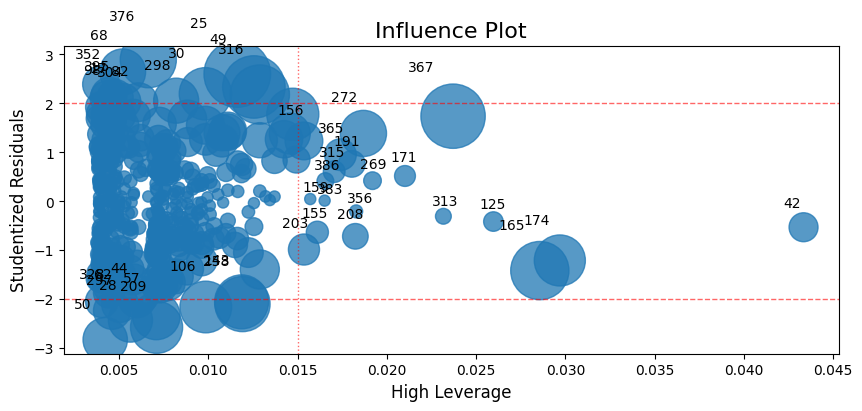

In [38]:
fig, ax = plt.subplots(figsize=(10, 4))
fig = influence_plot(results, ax=ax, criterion="cooks", plot_alpha=0.75)

ax.set_title("Influence Plot", fontsize=16)
ax.set_ylabel("Studentized Residuals", fontsize=12)
ax.set_xlabel("High Leverage", fontsize=12)
for txt in ax.texts:
    txt.set_fontsize(10)

ax.axhline(outlier_threshold, linestyle="--", linewidth=1, alpha=0.6, color='red')
ax.axhline(-outlier_threshold, linestyle="--", linewidth=1, alpha=0.6, color='red')
ax.axvline(leverage_threshold, linestyle=":", linewidth=1, alpha=0.6, color='red')

plt.show()

The plotted points are the residuals agains the leverage, which can be verified the outliers (in the y axis) and the high leverage observations as further they are to the right; the point size is the Cook's Distance itself.

The chart doesn't offer a clear view on the exact points that can be considered as influential to the model, but helps to verify the sensibility of the model, with not many points out of the defined thresholds.

#### Models with and without the Influential Points

##### With Influential Points

In [39]:
lin_reg_model = sm.OLS(y, X_const)

results_inf = lin_reg_model.fit()

print(30*'-', 'WITH Influential Points', 30*'-', '\n')
print(results_inf.summary())

------------------------------ WITH Influential Points ------------------------------ 

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           2.66e-24
Time:                        05:01:55   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

##### Without Influential Points

In [40]:
# retrieving the influential observations indexes
influential_idx = np.where(cooks_distance > cooks_threshold)[0]

X_wo_inf = X_const.drop(index=influential_idx)
y_wo_inf = y.drop(index=influential_idx)

df_wo_inf = df_feats_evidence.drop(index=influential_idx) # drops from the df with the features with evidence

lin_reg_model_wo_inf = sm.OLS(y_wo_inf, X_wo_inf)

results_wo_inf = lin_reg_model_wo_inf.fit()

print(30*'-', 'WITHOUT Influential Points', 30*'-', '\n')
print(results_wo_inf.summary())

------------------------------ WITHOUT Influential Points ------------------------------ 

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     60.75
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           1.33e-23
Time:                        05:01:56   Log-Likelihood:                -843.09
No. Observations:                 381   AIC:                             1692.
Df Residuals:                     378   BIC:                             1704.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

##### Plotting Regressions

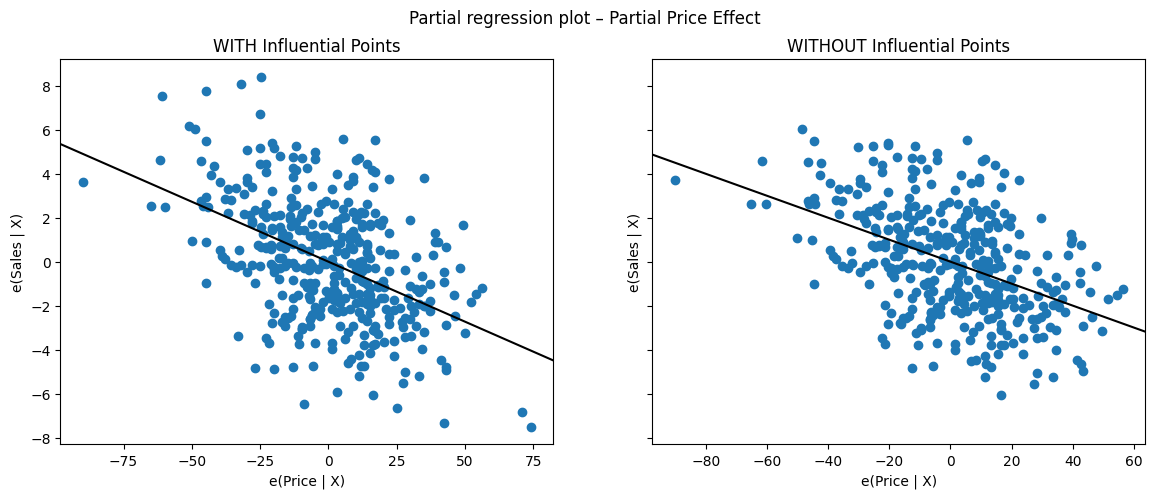

In [41]:
########### KEPT FOR CHECK, TO BE DELETED

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# model with the influent points
sm.graphics.plot_partregress(
    'Sales', 'Price',
    ['US_Yes'],
    data=df_feats_evidence,
    obs_labels=False,
    ax=axes[0]
)
axes[0].set_title("WITH Influential Points")

# model without the influent points
sm.graphics.plot_partregress(
    'Sales', 'Price',
    ['US_Yes'],
    data=df_wo_inf,
    obs_labels=False,
    ax=axes[1]
)
axes[1].set_title("WITHOUT Influential Points")

plt.suptitle("Partial regression plot – Partial Price Effect")
plt.show()


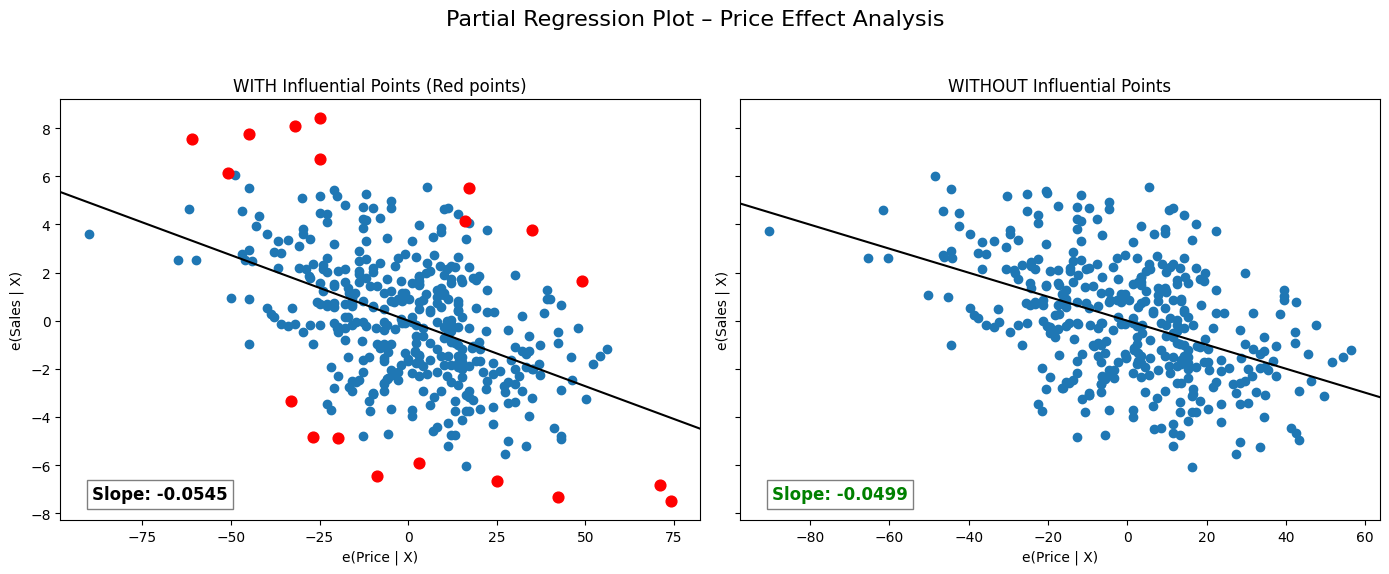

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

### model with influent points
sm.graphics.plot_partregress(
    'Sales', 'Price', ['US_Yes'],
    data=df_feats_evidence, obs_labels=False, ax=axes[0]
)

# setting the residual points locations
res_y = sm.OLS(df_feats_evidence['Sales'], sm.add_constant(df_feats_evidence['US_Yes'])).fit().resid
res_x = sm.OLS(df_feats_evidence['Price'], sm.add_constant(df_feats_evidence['US_Yes'])).fit().resid
axes[0].scatter(res_x.loc[influential_idx], res_y.loc[influential_idx], color='red', s=60, zorder=5, label='Influential')

# adding line slope
slope_1 = results.params['Price']
axes[0].text(0.05, 0.05, f'Slope: {slope_1:.4f}', transform=axes[0].transAxes, 
             fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
axes[0].set_title("WITH Influential Points (Red points)")

### model without the influent points
sm.graphics.plot_partregress(
    'Sales', 'Price', ['US_Yes'],
    data=df_wo_inf, obs_labels=False, ax=axes[1]
)

### model without the influent points
slope_2 = results_wo_inf.params['Price']
axes[1].text(0.05, 0.05, f'Slope: {slope_2:.4f}', transform=axes[1].transAxes, 
             fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5), color='green')
axes[1].set_title("WITHOUT Influential Points")

plt.suptitle("Partial Regression Plot – Price Effect Analysis", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The chart above has the Linear Partial plot, which is the plot of the residual error of each predictor; on its Y-axis it has the impact of the US_Yes (in case there were other variables, they would also be included) over the Sales, and on the X-axis the Price over the Sales.

It's shown in red the influential points flagged and how they clearly are floating apart of the regression mean line, returning a visual confirmation of the distance of these points from the prediction.

Even though, it's possible to check a reduction on the inclining of the line, having then a better adjust since it is focusing on the second plot only on the non-influential points, also numerically confirmed by the reduction of the slope value (from -0,0545 to -0,0499).

### Conclusion

* Yes, there is evidence of outliers and high leverage observations, but most important, there's also the occurence of both for the same observation. It means that there are influential points damaging the models sensibility;
* To measure the sensibility impact on the model, it was used the most common technique for this sort of problems: the Cook's distance calculation;
* After the definition of the Residuals Outliers and the High Leverage points, it was created a separated dataset WITHOUT these influential points;
* To properly verify this model sensibility, it's necessary to compare the original and this new model without the influential points, and analyze if the initial model has a high sensibility or not;
* The result of this analysis shows a slight increase of the Adjust R-squared, but not enough to affirm that the model is highly sensible (from 0,235 to 0,239);
* Regarding to the evidence of the features impact on the Sales, it can verified that all the p-values of the t-test remain below the 5% level of confidence, similarly also the confidence intervals which still not cross the zero value;
* There was a small reduction on the confidence interval amplitude, but as expected by analyzing the Adjusted R-squared, it is also not significant;
* Therefore, it can be concluded that even though the model has influential points, they are not impacting the model in a relevant way;
* This similar conclusion can be reached by using the partial regression plot above, where there is a change on the line slope which means that the line was readjusted but not in a significant value.